<a href="https://colab.research.google.com/github/DenisDrobyshev/universum/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%969_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8_YOLOv12_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D0%B4%D0%B5%D1%82%D0%B5%D0%BA%D1%86%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №9. Использование модели YOLOv26 для решение задач детекции и классификации**

## **Задание 1. Знакомство с новейшей версией модели YOLO**

- Ознакомьтесь с технической документацией по новейшей версии модели YOLOv26: https://docs.ultralytics.com/ru/models/yolo26/

- Рассмотрите пример обучения этой модели c использованием датасетов, созданных в Roboflow: https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolo26-object-detection-on-custom-dataset.ipynb?ref=blog.roboflow.com

### **Ответьте на вопрос: Какие принципиальные отличия появились в модели YOLOv26 относительно предыдущих версий?**

Главное отличие YOLOv26 от предыдущих версий — это полный переход на "сквозную" (End-to-End) архитектуру без использования Non-Maximum Suppression (NMS)

YOLOv26 достигает более высокой точности на небольших объектах, обеспечивает бесшовное развертывание и работает до 43% быстрее на CPU, что делает YOLO26 одной из самых практичных и удобных для развертывания моделей YOLO на сегодняшний день для сред с ограниченными ресурсами.

*Примечание:* для каждого последующего задания, в конечном итоге, необходимо сформировать обученную модель и задеплоить её на сервисе **RoboFlow**



## **Задание 2. Найдите готовый датасет для детекции объектов и обучите на нем модель YOLOv26:**

- Для удобства работы с датасетом и деплоя модели используйте сервис [RoboFlow](https://roboflow.com/)

In [24]:
!pip install roboflow ultralytics

In [25]:
from roboflow import Roboflow

rf = Roboflow(api_key="hQAwS7KOn08k9jEKFyI1")

project = rf.workspace("ashu-s9lfx").project("fish-j2vym")
dataset = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


In [26]:
import yaml

# читаем data.yaml
with open(dataset.location + "/data.yaml", 'r') as f:
    data_yaml = yaml.safe_load(f)

print("Количество классов:", data_yaml['nc'])
print("Список классов:")

for i, name in enumerate(data_yaml['names']):
    print(f"{i}: {name}")

Количество классов: 1
Список классов:
0: fish


In [27]:
from ultralytics import YOLO

# Загружаем предобученную модель
model = YOLO("yolo26n.pt")

# Запуск обучения
model.train(
    data=dataset.location + "/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    name="fishs_model"
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/fish-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fishs_model-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a05b021ed50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [32]:
best_model_path = "runs/detect/fishs_model-2/weights/best.pt"
print("Модель сохранена здесь:", best_model_path)

Модель сохранена здесь: runs/detect/fishs_model-2/weights/best.pt


In [33]:
from google.colab import files

uploaded = files.upload()

Saving 360_F_924012876_1NcAJM7NOtdF1pPdExbcKW564L6wIQSN.jpg to 360_F_924012876_1NcAJM7NOtdF1pPdExbcKW564L6wIQSN (1).jpg


In [34]:
from ultralytics import YOLO

# загружаем обученную модель
model = YOLO(best_model_path)

# берем имя загруженного файла
image_path = list(uploaded.keys())[0]

# делаем предсказание
results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)


image 1/1 /content/360_F_924012876_1NcAJM7NOtdF1pPdExbcKW564L6wIQSN (1).jpg: 384x640 1 fish, 95.1ms
Speed: 2.9ms preprocess, 95.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict-4


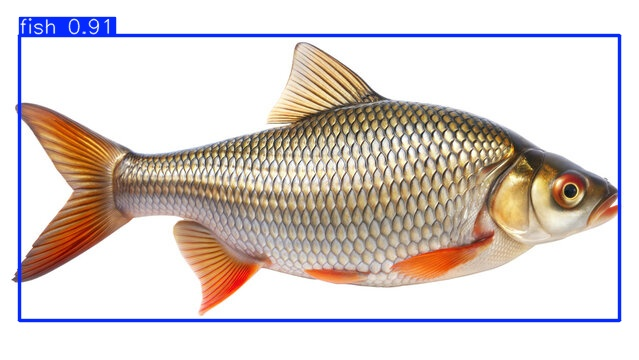

In [36]:
from IPython.display import Image, display
import glob

result_image = glob.glob("runs/detect/predict-4/*.jpg")[0]

display(Image(filename=result_image))

In [39]:
import roboflow
import os
import shutil

WORKSPACE_NAME = "dennys-workspace-fm2bf"
PROJECT_NAME = "fish-cgcm5"
VERSION_NUMBER = "1"


MODEL_PATH = "runs/detect/fishs_model-2/weights/best.pt"

rf = roboflow.Roboflow(api_key="hQAwS7KOn08k9jEKFyI1")

project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)

print(f"Проект: {PROJECT_NAME}")

# Подготовка
model_dir = "model_for_deploy"
weights_dir = os.path.join(model_dir, "weights")
os.makedirs(weights_dir, exist_ok=True)

shutil.copy(MODEL_PATH, os.path.join(weights_dir, "best.pt"))

# Деплой
version.deploy(
    model_type="yolo26n",
    model_path=model_dir
)

print("\n✅ Модель задеплоена в fish-cgcm5!")

loading Roboflow workspace...
loading Roboflow project...
Проект: fish-cgcm5
View the status of your deployment at: https://app.roboflow.com/dennys-workspace-fm2bf/fish-cgcm5/1
Share your model with the world at: https://universe.roboflow.com/dennys-workspace-fm2bf/fish-cgcm5/model/1

✅ Модель задеплоена в fish-cgcm5!


In [42]:
!pip install supervision inference

In [41]:
import getpass
import supervision as sv
from inference import get_model

# Введи свой API ключ
print("Введите ваш Roboflow API ключ:")
ROBOFLOW_API_KEY = getpass.getpass()

# ТВОИ ДАННЫЕ
model_id = "fish-cgcm5/1"  # проект fish-cgcm5, версия 1

deployed_model = get_model(
    model_id=model_id,
    api_key=ROBOFLOW_API_KEY
)

print(f"Модель загружена: {model_id}")

ModelDependencyMissing: Your `inference` configuration does not support SAM3 model. Install SAM3 dependencies and set CORE_MODEL_SAM3_ENABLED to True.
ModelDependencyMissing: Your `inference` configuration does not support Gaze Detection model. Use pip install 'inference[gaze]' to install missing requirements.To suppress this warning, set CORE_MODEL_GAZE_ENABLED to False.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.


Error importing huggingface_hub._login: cannot import name 'split_arg_string' from partially initialized module 'click.shell_completion' (most likely due to a circular import) (/usr/local/lib/python3.12/dist-packages/click/shell_completion.py)
Введите ваш Roboflow API ключ:
··········


Output()

Модель загружена: fish-cgcm5/1


loading Roboflow workspace...
loading Roboflow project...
Загрузи тестовое изображение рыбы:


Saving 360_F_924012876_1NcAJM7NOtdF1pPdExbcKW564L6wIQSN.jpg to 360_F_924012876_1NcAJM7NOtdF1pPdExbcKW564L6wIQSN (2).jpg

Изображение: 360_F_924012876_1NcAJM7NOtdF1pPdExbcKW564L6wIQSN (2).jpg
Найдено объектов: 1
  - fish: 86.78%


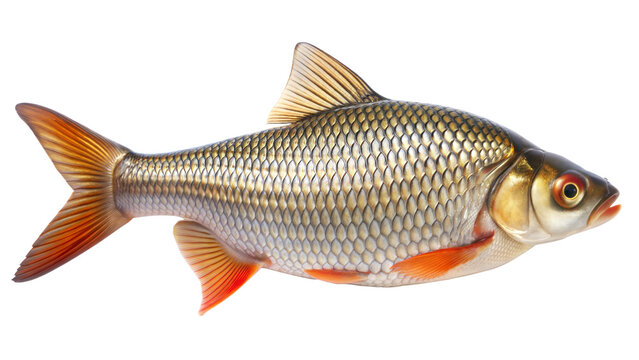

In [43]:
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from roboflow import Roboflow

# ТВОИ ДАННЫЕ
WORKSPACE_NAME = "dennys-workspace-fm2bf"
PROJECT_NAME = "fish-cgcm5"
VERSION_NUMBER = "1"

# Авторизация
ROBOFLOW_API_KEY = "hQAwS7KOn08k9jEKFyI1"  # или используй ввод выше
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

# Загрузка модели
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
cloud_model = project.version(VERSION_NUMBER).model

# Папка с тестовыми изображениями (загрузи свои фото рыб)
from google.colab import files
print("Загрузи тестовое изображение рыбы:")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Инференс
result = cloud_model.predict(image_path, confidence=40).json()

# Показываем результат
from IPython.display import Image, display
import cv2
import urllib

# Скачиваем изображение с разметкой
annotated_image_url = cloud_model.predict(image_path, confidence=40).json()
# Лучше просто покажем предсказания
print(f"\nИзображение: {image_path}")
print(f"Найдено объектов: {len(result['predictions'])}")

for pred in result['predictions']:
    print(f"  - {pred['class']}: {pred['confidence']:.2%}")

# Показываем оригинал
display(Image(filename=image_path))

## **Задание 3. Сформируйте свой датасет для детекции объектов и обучите на нем модель YOLOv26**



Требования к датасету:

- Количество изображений в датасете: минимум 90
- Количество классов: более 2х
- Обязательно должны присутствовать изображения, содержащие несколько классов одновременно


*Примечание: Формирование датасета включает в себя поиск изображений и ручное аннотирование объектов на изображениях.*

In [44]:
!pip install roboflow ultralytics

In [45]:
from roboflow import Roboflow

rf = Roboflow(api_key="hQAwS7KOn08k9jEKFyI1")

project = rf.workspace("classroomviolations").project("fruitdetection-1fptq")
dataset = project.version(3).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FruitDetection-3 in yolov8:: 100%|██████████| 257/257 [00:00<00:00, 8739.34it/s]


In [46]:
import yaml

# читаем data.yaml
with open(dataset.location + "/data.yaml", 'r') as f:
    data_yaml = yaml.safe_load(f)

print("Количество классов:", data_yaml['nc'])
print("Список классов:")

for i, name in enumerate(data_yaml['names']):
    print(f"{i}: {name}")

Количество классов: 3
Список классов:
0: apple
1: banana
2: strawberry


Пример изображения:


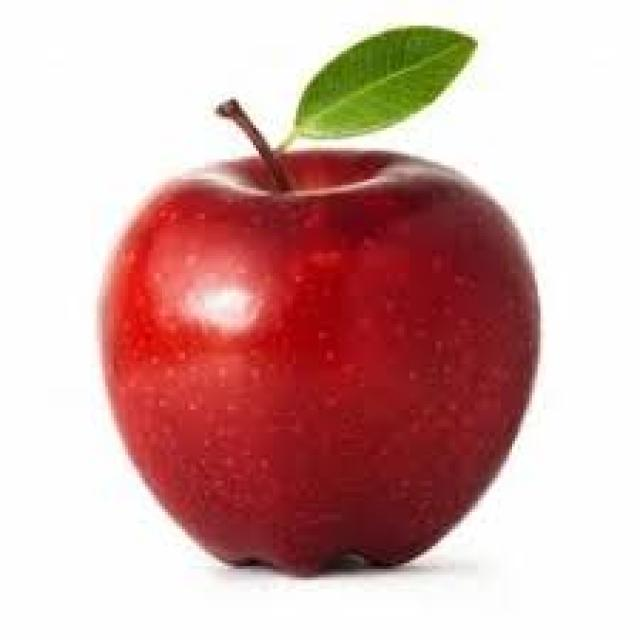

In [47]:
import os
import random
from IPython.display import Image, display

images_path = dataset.location + "/train/images"
random_image = random.choice(os.listdir(images_path))

print("Пример изображения:")
display(Image(filename=os.path.join(images_path, random_image)))

In [48]:
from ultralytics import YOLO

# Загружаем предобученную модель
model = YOLO("yolo26n.pt")

# Запуск обучения
model.train(
    data=dataset.location + "/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="fruit_detection_model"
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FruitDetection-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fruit_detection_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_ma

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a061c7a9550>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [56]:
best_model_path = "/content/runs/detect/fruit_detection_model/weights/best.pt"
print("Модель сохранена здесь:", best_model_path)

Модель сохранена здесь: /content/runs/detect/fruit_detection_model/weights/best.pt


In [81]:
WORKSPACE_NAME = "dennys-workspace-fm2bf"
PROJECT_NAME = "fructdetection"
VERSION_NUMBER = "1"
API_KEY = "NbCjAL8dZBb5vAQhvh7y"

In [70]:
from google.colab import files

uploaded = files.upload()

Saving photo_2026-05-06_02-16-04.jpg to photo_2026-05-06_02-16-04.jpg


In [71]:
from ultralytics import YOLO

# загружаем обученную модель
model = YOLO(best_model_path)

# берем имя загруженного файла
image_path = list(uploaded.keys())[0]

# делаем предсказание
results = model.predict(
    source=image_path,
    conf=0.25,
    save=True
)


image 1/1 /content/photo_2026-05-06_02-16-04.jpg: 640x640 (no detections), 13.9ms
Speed: 3.3ms preprocess, 13.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-10


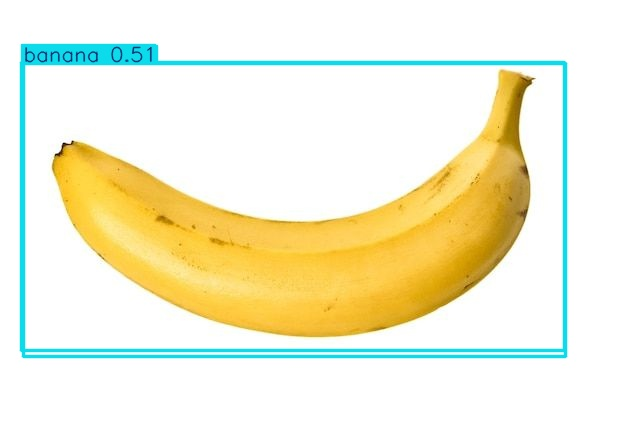

In [60]:
from IPython.display import Image, display
import glob

result_image = glob.glob("runs/detect/predict-6/*.jpg")[0]

display(Image(filename=result_image))

In [85]:
import roboflow

WORKSPACE_NAME = "classroomviolations"
PROJECT_NAME = "fruitdetection-1fptq"
VERSION_NUMBER = "4"
# dir = "bestpr9p1.pt"
dir = "/content/runs/detect/fruit_detection_model/weights/best.pt"

# Проверяем, что авторизация выполнена
rf = roboflow.Roboflow(api_key="NbCjAL8dZBb5vAQhvh7y")

# Получаем проект
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)

print(f"Проект: {PROJECT_NAME}")
print(f"Версия: {VERSION_NUMBER}")
print(f"Путь к обученной модели: {dir}")

loading Roboflow workspace...
loading Roboflow project...
Проект: fruitdetection-1fptq
Версия: 4
Путь к обученной модели: /content/runs/detect/fruit_detection_model/weights/best.pt


In [86]:
import os
from pathlib import Path

model_file = "/content/runs/detect/fruit_detection_model/weights/best.pt"

# Создаем правильную структуру директорий
model_dir = "model_for_deploy"
weights_dir = os.path.join(model_dir, "weights")
os.makedirs(weights_dir, exist_ok=True)

# Копируем файл в нужное место
import shutil
shutil.copy(model_file, os.path.join(weights_dir, "best.pt"))

# Теперь развертываем
version.deploy(
    model_type="yolo26n",
    model_path=model_dir  # указываем на созданную директорию
)

print("\n" + "=" * 50)
print("Модель успешно загружена в Roboflow!")
print(f"Model ID: {PROJECT_NAME}")

View the status of your deployment at: https://app.roboflow.com/classroomviolations/fruitdetection-1fptq/4
Share your model with the world at: https://universe.roboflow.com/classroomviolations/fruitdetection-1fptq/model/4

Модель успешно загружена в Roboflow!
Model ID: fruitdetection-1fptq


In [ ]:
!pip install supervision inference

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.7/105.7 kB 7.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB

In [75]:
import getpass
import supervision as sv
from inference import get_model

# Безопасный ввод API-ключа
print("Введите ваш Roboflow API ключ:")
ROBOFLOW_API_KEY = getpass.getpass()

# Загрузка модели из Roboflow
model_id = f"fruitdetection-1fptq/3"
deployed_model = get_model(
    model_id=model_id,
    api_key=ROBOFLOW_API_KEY
)

print(f"Модель загружена: {model_id}")

Введите ваш Roboflow API ключ:
··········


Output()

Модель загружена: fruitdetection-1fptq/3


## **Задание 4 (для магистрантов). Обучите модель YOLOv26 на датасете [RSD-GOD](https://github.com/Dr-Zhuang/geospatial-object-detection). Затем самостоятельно сформируйте тестовые данные (не менее 50 изображений с аннотациями) и оцените качество обученной модели:**



**Прямая ссылка на загрузку датасета: [загрузить](https://drive.google.com/open?id=1ttvSta0BRxW7tTV_st89vSb_obHVre34)**

**Ссылка на датасет в среде roboflow universe:** https://universe.roboflow.com/animals-sqrdn/rsd-god

 *Примечание: для поиска данных удобно использовать сервис Google Earth/Google Earth Engine*

In [ ]:
# Ваш код